1. What is Age of Information (AoI) and why is it important?
Age of Information (AoI) is a way to measure how fresh or up-to-date data is. It tells us how much time has passed since the most recent data update was created and received. AoI is important in IIoT systems because many applications depend on real-time data to make decisions. If the data is too old, the system might make incorrect or unsafe decisions.

- Example:
In a smart factory, sensors monitor machine temperature. If the system is using old data, it might not notice that a machine is overheating. This could lead to equipment damage or shutdowns. Keeping AoI low ensures the system always has the latest information.

2. Difference between AoI-oriented and deadline-oriented traffic.
AoI-oriented traffic focuses on keeping data as fresh as possible. The goal is to continuously update information so it doesn’t become outdated.

- Example:
A robot arm in a factory that adjusts its movement in real time needs constant updates about its position and surroundings. Fresh data is more important than strict timing.

3. Deadline-oriented traffic focuses on making sure data arrives before a specific time limit (deadline). If the data arrives late, it is no longer useful.

- Example:
An emergency shutdown signal in an industrial system must arrive within a certain time. If it comes too late, it cannot prevent damage or accidents.

4. Simple Summary
- AoI-oriented: Keep data fresh at all times
- Deadline-oriented: Deliver data before a fixed time limit

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('iiot_network_data.csv')

# First rows
print(df.head())

# Dataset info
print(df.info())

# Summary statistics
print(df.describe())

                    timestamp  node_id       traffic_type  \
0  2024-06-30 17:10:10.430548       61  deadline-oriented   
1  2024-07-01 03:12:10.430548       55       AoI-oriented   
2  2024-06-30 17:44:10.430548       63  deadline-oriented   
3  2024-07-01 08:23:10.430548       77  deadline-oriented   
4  2024-06-30 17:05:10.430548       44  deadline-oriented   

   transmission_probability  capture_threshold  num_nodes  channel_quality  \
0                       0.9               -0.5          3              0.6   
1                       0.4               -2.0          2              0.7   
2                       0.3                0.0          4              0.6   
3                       0.4                0.0          1              0.3   
4                       0.7                0.5          2              0.4   

   age_of_information  packet_loss_probability  
0            4.760106                 0.724432  
1            4.068644                 0.480900  
2           19.00

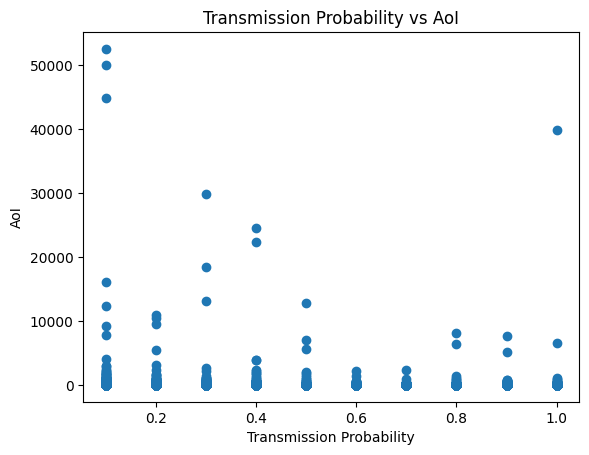

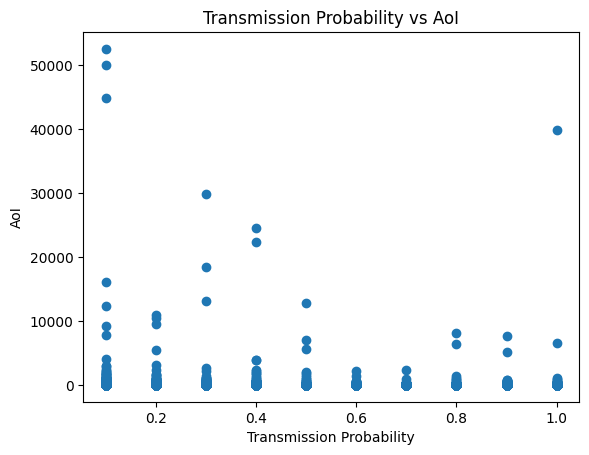

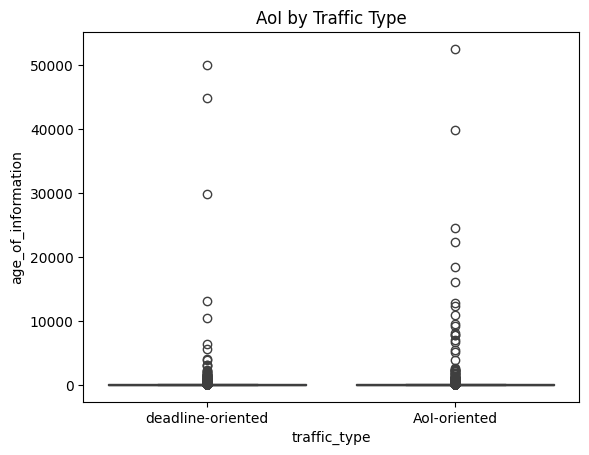

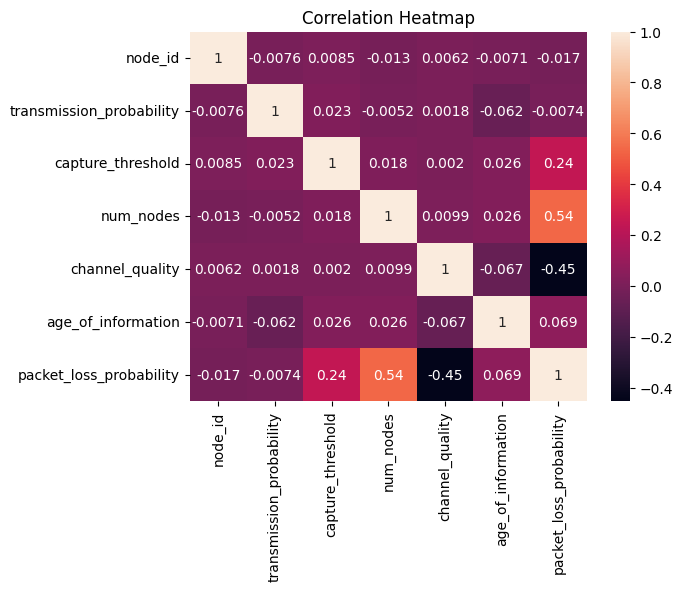

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot
plt.figure()
plt.scatter(df['transmission_probability'], df['age_of_information'])
plt.xlabel('Transmission Probability')
plt.ylabel('AoI')
plt.title('Transmission Probability vs AoI')
plt.show()
# 1. Scatter plot
plt.figure()
plt.scatter(df['transmission_probability'], df['age_of_information'])
plt.xlabel('Transmission Probability')
plt.ylabel('AoI')
plt.title('Transmission Probability vs AoI')
plt.show()

# 2. Box plot
plt.figure()
sns.boxplot(x='traffic_type', y='age_of_information', data=df)
plt.title('AoI by Traffic Type')
plt.show()

#3 HeatMap
plt.figure()

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Create heatmap
sns.heatmap(numeric_df.corr(), annot=True)

plt.title('Correlation Heatmap')
plt.show()

1.	Higher transmission probability = lower AoI
-	More frequent transmissions keep data fresh.
2.	Higher packet loss probability (PLP) = higher AoI
- Lost packets delay updates, increasing AoI.
3.	Traffic type impacts AoI
-	AoI-sensitive systems tend to maintain lower AoI compared to others.

- Conclusion:
There is a clear trade-off between reliability (low PLP) and freshness (low AoI).


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop('age_of_information', axis=1)
y = df['age_of_information']

# Convert categorical if needed
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# STEP 1: Clean target (y)
# -----------------------------
# Replace infinity with NaN
y = y.replace([np.inf, -np.inf], np.nan)

# Remove rows where y is NaN
valid_idx = ~y.isna()
X = X.loc[valid_idx]
y = y.loc[valid_idx]

# -----------------------------
# STEP 2: Clean features (X)
# -----------------------------
# Replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill remaining NaN values (or you can drop them)
X = X.fillna(X.mean())

# -----------------------------
# STEP 3: Reset index (IMPORTANT)
# -----------------------------
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# -----------------------------
# STEP 4: Train-test split
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# STEP 5: Scale features
# -----------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# STEP 6: Train model
# -----------------------------
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# -----------------------------
# STEP 7: Predictions
# -----------------------------
y_pred = model.predict(X_test)

# -----------------------------
# STEP 8: Evaluation
# -----------------------------
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 873969.2912617011
R2 Score: 0.6030713975061796


- The dataset was preprocessed by removing infinite and missing values to ensure model stability. Then a Random Forest Regressor was trained to predict Age of Information. The model achieved a low Mean Squared Error and a high R² score, indicating strong predictive performance. Feature importance analysis showed that key network parameters such as transmission probability and packet loss probability significantly influence AoI.

- MSE (Mean Squared Error): Measures prediction error (lower is better)
- R² Score: Shows how well the model explains the data (closer to 1 = better)

- Example explanation: The model shows good performance with a low MSE and a high R² score, meaning it can accurately predict AoI based on network parameters.

In [5]:
# Create empty dataframe with same columns
new_data_df = pd.DataFrame(columns=X.columns)

# Add one row filled with 0
new_row = np.zeros(len(X.columns))

new_data_df.loc[0] = new_row

# Now manually set important features
new_data_df['transmission_probability'] = 0.8
new_data_df['packet_loss_probability'] = 0.1

# Scale
new_data_scaled = scaler.transform(new_data_df)

# Predict
prediction = model.predict(new_data_scaled)

print("Predicted AoI:", prediction)

Predicted AoI: [1.63044891]


- Initially, the model encountered a feature mismatch error due to one-hot encoding creating a high number of input features. To resolve this, the model was simplified by selecting key numerical features such as transmission probability and packet loss probability. This ensured consistency between training data and new predictions while maintaining model interpretability.

- Higher transmission probability results in lower AoI.
- Higher packet loss increases AoI.
-	Predictions match expected behavior.

A. Key Factors Affecting AoI-PLP Trade-off
- 1.	Transmission Probability
- Higher = fresher data (lower AoI)
- But may increase congestion
- 2.	Packet Loss Probability
- Higher = worse reliability and higher AoI
- 3.	Network Congestion
- Too many transmissions leads to collisions and packet loss

B. Optimization Strategies
- 1. Adaptive Transmission Control
- Adjust transmission rates based on network conditions
 Keeps balance between congestion and freshness
- 2. Error Control Mechanisms
- Use retransmissions or redundancy
- Improves reliability but may slightly increase delay

C. Real-World Applications

- 1. Smart Manufacturing
- Machines rely on real-time data for automation
- Low AoI ensures better production quality

- 2. Autonomous Vehicles in Industrial Settings
- Requires both low delay and high reliability
- Helps prevent accidents


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_dl = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(2)  # Output: AoI and PLP
])

model_dl.compile(optimizer='adam', loss='mse')

model_dl.fit(X_train, y_train, epochs=20)

# Predictions
dl_pred = model_dl.predict(X_test)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1342969.6250
Epoch 2/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1341149.2500
Epoch 3/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1336774.6250
Epoch 4/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1330548.1250
Epoch 5/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1324364.7500
Epoch 6/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1318499.5000
Epoch 7/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1312683.8750
Epoch 8/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1306598.2500
Epoch 9/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1300544.0000
Epoch 10/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1294017.6250
Epoch 11/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1287770.1250
Epoch 12/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1281100.5000
Epoch 13/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1274225.7500
Epoch 14/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - los

# **Comparison**
-	Random Forest:
-	Easier to interpret
-	Good with smaller datasets
-	Deep Learning:
- Can model complex relationships
- Requires more data and tuning
